# Credit Card Fraud Detection - Exploratory Data Analysis (EDA)

## Step 1: Define Objective

### Project Goal
The primary objective of this EDA is to analyze a credit card fraud detection dataset to:

1. **Understand the data structure and quality** - Examine the dataset's characteristics, data types, and completeness
2. **Identify patterns in fraudulent vs legitimate transactions** - Find distinguishing features between fraud (Class=1) and normal (Class=0) transactions
3. **Detect outliers and anomalies** - Identify unusual patterns that might indicate fraud
4. **Prepare data for machine learning** - Clean and engineer features for potential model training
5. **Communicate insights through visualizations** - Create meaningful plots to understand the data distribution and relationships

### Key Questions to Explore
- What is the distribution of fraudulent vs legitimate transactions?
- Which features (V1-V28) are most important for distinguishing fraud?
- Are there temporal patterns in fraud occurrence?
- What are the typical amounts for fraudulent transactions?
- Are there any data quality issues that need addressing?

### Expected Outcomes
- Comprehensive understanding of the dataset structure
- Identification of key fraud indicators
- Clean, analysis-ready dataset
- Visual insights for stakeholders
- Foundation for building fraud detection models


## Step 2: Load Data

Let's import the necessary libraries and load our credit card dataset to understand what we're working with.


In [14]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('creditcard.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset Shape: (284807, 31)

First few rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 3: Step 3: Understand data types - Analyze column types and plan visualizations

In [15]:
# Check the target variable distribution
print("Target Variable (Class) Distribution:")
print("="*50)
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean()*100:.2f}%")
print(f"Normal transactions: {df['Class'].value_counts()[0]:,}")
print(f"Fraudulent transactions: {df['Class'].value_counts()[1]:,}")


Target Variable (Class) Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.17%
Normal transactions: 284,315
Fraudulent transactions: 492


In [16]:
# COMPREHENSIVE DATA ANALYSIS WITH SWEETVIZ
# This will create an interactive HTML report that opens in your browser

print("Generating comprehensive EDA report with Sweetviz...")
print("="*60)

# Create Sweetviz report
report = sv.analyze(df, target_feat='Class')

# Generate and show the report in browser
report.show_html('creditcard_EDA_report.html', open_browser=True)

print("✅ Sweetviz report generated successfully!")
print("📊 Report saved as 'creditcard_EDA_report.html'")
print("🌐 The report should open automatically in your browser")
print("\nThe report includes:")
print("• Dataset overview and statistics")
print("• Individual feature analysis")
print("• Target variable analysis")
print("• Feature correlations")
print("• Missing value analysis")
print("• Data type information")
print("• Distribution plots for all features")
print("• Association analysis between features")


Generating comprehensive EDA report with Sweetviz...


                                             |          | [  0%]   00:00 -> (? left)

Report creditcard_EDA_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
✅ Sweetviz report generated successfully!
📊 Report saved as 'creditcard_EDA_report.html'
🌐 The report should open automatically in your browser

The report includes:
• Dataset overview and statistics
• Individual feature analysis
• Target variable analysis
• Feature correlations
• Missing value analysis
• Data type information
• Distribution plots for all features
• Association analysis between features


In [17]:
# Additional comprehensive analysis with custom visualizations
print("\n" + "="*60)
print("ADDITIONAL CUSTOM ANALYSIS")
print("="*60)

# 1. Dataset Overview
print("📊 DATASET OVERVIEW:")
print(f"• Total transactions: {df.shape[0]:,}")
print(f"• Total features: {df.shape[1]}")
print(f"• Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 2. Target Variable Analysis
print(f"\n🎯 FRAUD ANALYSIS:")
fraud_count = df['Class'].value_counts()
print(f"• Normal transactions: {fraud_count[0]:,} ({fraud_count[0]/len(df)*100:.2f}%)")
print(f"• Fraudulent transactions: {fraud_count[1]:,} ({fraud_count[1]/len(df)*100:.2f}%)")
print(f"• Fraud rate: {df['Class'].mean()*100:.2f}%")

# 3. Data Quality Check
print(f"\n🔍 DATA QUALITY:")
print(f"• Missing values: {df.isnull().sum().sum()}")
print(f"• Duplicate rows: {df.duplicated().sum()}")
print(f"• Data types: {df.dtypes.value_counts().to_dict()}")

# 4. Amount Analysis
print(f"\n💰 TRANSACTION AMOUNTS:")
print(f"• Average amount: ${df['Amount'].mean():.2f}")
print(f"• Median amount: ${df['Amount'].median():.2f}")
print(f"• Max amount: ${df['Amount'].max():.2f}")
print(f"• Min amount: ${df['Amount'].min():.2f}")

# 5. Time Analysis
print(f"\n⏰ TIME ANALYSIS:")
print(f"• Time range: {df['Time'].min():.0f} to {df['Time'].max():.0f} seconds")
print(f"• Duration: {(df['Time'].max() - df['Time'].min())/3600:.1f} hours")



ADDITIONAL CUSTOM ANALYSIS
📊 DATASET OVERVIEW:
• Total transactions: 284,807
• Total features: 31
• Memory usage: 67.36 MB

🎯 FRAUD ANALYSIS:
• Normal transactions: 284,315 (99.83%)
• Fraudulent transactions: 492 (0.17%)
• Fraud rate: 0.17%

🔍 DATA QUALITY:
• Missing values: 0
• Duplicate rows: 1081
• Data types: {dtype('float64'): 30, dtype('int64'): 1}

💰 TRANSACTION AMOUNTS:
• Average amount: $88.35
• Median amount: $22.00
• Max amount: $25691.16
• Min amount: $0.00

⏰ TIME ANALYSIS:
• Time range: 0 to 172792 seconds
• Duration: 48.0 hours



📈 CREATING CUSTOM VISUALIZATIONS...


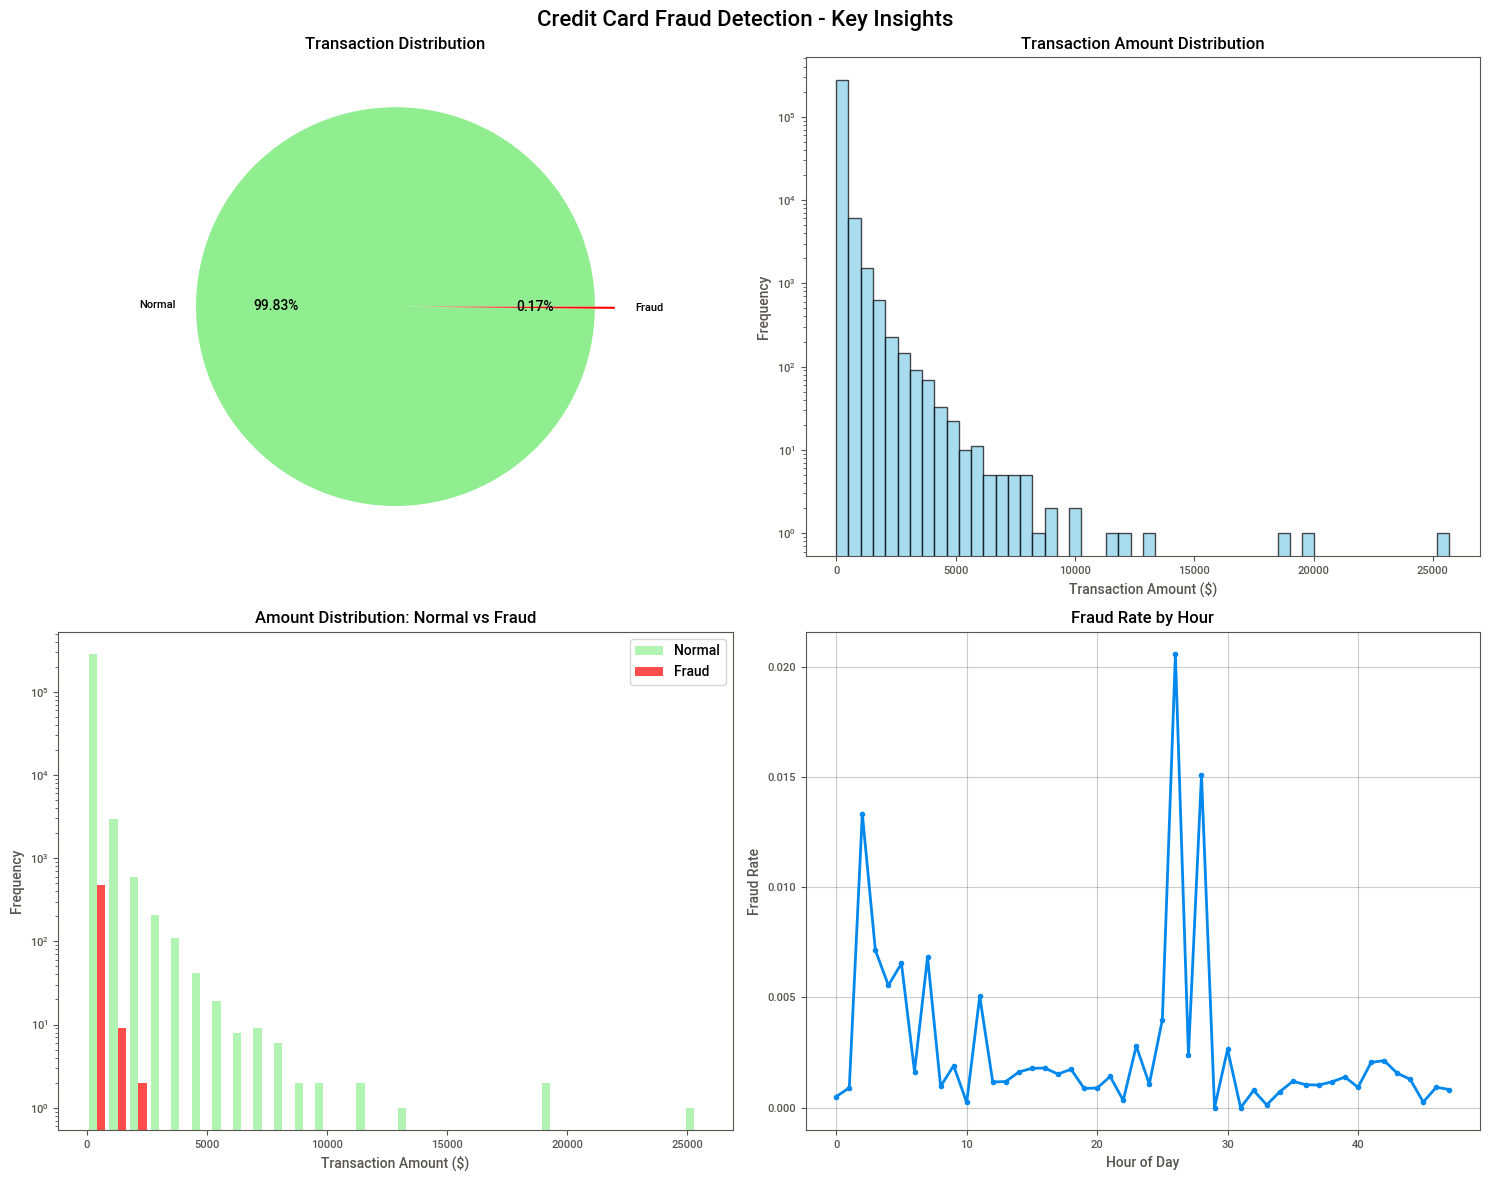

✅ Custom visualizations created!
📊 Sweetviz report provides comprehensive interactive analysis
🌐 Check your browser for the detailed HTML report


In [18]:
# Create additional custom visualizations
print("\n📈 CREATING CUSTOM VISUALIZATIONS...")

# Set up the plotting area
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Credit Card Fraud Detection - Key Insights', fontsize=16, fontweight='bold')

# 1. Fraud Distribution
axes[0,0].pie([fraud_count[0], fraud_count[1]], 
              labels=['Normal', 'Fraud'], 
              autopct='%1.2f%%', 
              colors=['lightgreen', 'red'],
              explode=(0, 0.1))
axes[0,0].set_title('Transaction Distribution')

# 2. Amount Distribution (log scale)
axes[0,1].hist(df['Amount'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,1].set_xlabel('Transaction Amount ($)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Transaction Amount Distribution')
axes[0,1].set_yscale('log')

# 3. Fraud vs Amount
fraud_data = df[df['Class'] == 1]['Amount']
normal_data = df[df['Class'] == 0]['Amount']

axes[1,0].hist([normal_data, fraud_data], 
               bins=30, 
               alpha=0.7, 
               label=['Normal', 'Fraud'],
               color=['lightgreen', 'red'])
axes[1,0].set_xlabel('Transaction Amount ($)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Amount Distribution: Normal vs Fraud')
axes[1,0].legend()
axes[1,0].set_yscale('log')

# 4. Time vs Fraud
time_fraud = df.groupby(df['Time'] // 3600)['Class'].mean()  # Hourly fraud rate
axes[1,1].plot(time_fraud.index, time_fraud.values, marker='o', linewidth=2)
axes[1,1].set_xlabel('Hour of Day')
axes[1,1].set_ylabel('Fraud Rate')
axes[1,1].set_title('Fraud Rate by Hour')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Custom visualizations created!")
print("📊 Sweetviz report provides comprehensive interactive analysis")
print("🌐 Check your browser for the detailed HTML report")


## Step 4: Handle Missing/Duplicate Data - Ensure Data Integrity

Let's check for duplicates and ensure our dataset has data integrity.


In [19]:
# STEP 4: DATA INTEGRITY ANALYSIS
print("🔍 DATA INTEGRITY ANALYSIS")
print("="*50)

# 1. Check for missing values
print("1️⃣ MISSING VALUES CHECK:")
missing_values = df.isnull().sum()
total_missing = missing_values.sum()
print(f"Total missing values: {total_missing}")
if total_missing > 0:
    print("Missing values by column:")
    print(missing_values[missing_values > 0])
else:
    print("✅ No missing values found!")

print("\n" + "="*50)

# 2. Check for duplicate rows
print("2️⃣ DUPLICATE ROWS CHECK:")
duplicate_rows = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_rows}")
print(f"Percentage of duplicates: {(duplicate_rows/len(df))*100:.4f}%")

if duplicate_rows > 0:
    print("\n🔍 Analyzing duplicate rows...")
    duplicate_data = df[df.duplicated(keep=False)]
    print(f"Number of rows involved in duplicates: {len(duplicate_data)}")
    
    # Check if duplicates contain fraud cases
    fraud_in_duplicates = duplicate_data['Class'].sum()
    print(f"Fraud cases in duplicates: {fraud_in_duplicates}")
    
    if fraud_in_duplicates > 0:
        print("⚠️  WARNING: Duplicate rows contain fraud cases!")
        print("This could indicate data collection issues or legitimate repeated transactions.")
else:
    print("✅ No duplicate rows found!")


🔍 DATA INTEGRITY ANALYSIS
1️⃣ MISSING VALUES CHECK:
Total missing values: 0
✅ No missing values found!

2️⃣ DUPLICATE ROWS CHECK:
Total duplicate rows: 1081
Percentage of duplicates: 0.3796%

🔍 Analyzing duplicate rows...
Number of rows involved in duplicates: 1854
Fraud cases in duplicates: 32
⚠️  WARNING: Duplicate rows contain fraud cases!
This could indicate data collection issues or legitimate repeated transactions.


In [20]:
# 3. Data integrity checks
print("\n3️⃣ DATA INTEGRITY CHECKS:")
print("="*50)

# Check for negative amounts (should be rare in credit card transactions)
negative_amounts = (df['Amount'] < 0).sum()
print(f"Negative amounts: {negative_amounts}")

# Check for zero amounts
zero_amounts = (df['Amount'] == 0).sum()
print(f"Zero amounts: {zero_amounts}")

# Check for extremely high amounts (potential outliers)
high_amounts = (df['Amount'] > 10000).sum()
print(f"Amounts > $10,000: {high_amounts}")

# Check Class variable integrity
print(f"\nClass variable values: {df['Class'].unique()}")
print(f"Class value counts: {df['Class'].value_counts().to_dict()}")

# Check for any non-numeric values in numeric columns
print(f"\nData types check:")
print(df.dtypes)



3️⃣ DATA INTEGRITY CHECKS:
Negative amounts: 0
Zero amounts: 1825
Amounts > $10,000: 7

Class variable values: [0 1]
Class value counts: {0: 284315, 1: 492}

Data types check:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [21]:
# 4. Handle duplicates 
print("\n4️⃣ DUPLICATE HANDLING:")
print("="*50)

if duplicate_rows > 0:
    print("🔧 HANDLING DUPLICATES:")
    
    # Show some examples of duplicate rows
    print("\nExample duplicate rows:")
    duplicate_examples = df[df.duplicated(keep=False)].head(10)
    print(duplicate_examples[['Time', 'Amount', 'Class']].to_string())
    
    # Decision: Remove duplicates but keep first occurrence
    print(f"\nRemoving {duplicate_rows} duplicate rows...")
    df_cleaned = df.drop_duplicates(keep='first')
    
    print(f"Original dataset size: {df.shape}")
    print(f"Cleaned dataset size: {df_cleaned.shape}")
    print(f"Rows removed: {df.shape[0] - df_cleaned.shape[0]}")
    
    # Update the main dataframe
    df = df_cleaned.copy()
    print("✅ Duplicates removed successfully!")
    
    # Check fraud distribution after cleaning
    print(f"\nFraud distribution after cleaning:")
    print(f"Normal transactions: {df['Class'].value_counts()[0]:,}")
    print(f"Fraudulent transactions: {df['Class'].value_counts()[1]:,}")
    print(f"Fraud rate: {df['Class'].mean()*100:.2f}%")
    
else:
    print("✅ No duplicates to handle - dataset is clean!")
    print("Dataset integrity is maintained.")



4️⃣ DUPLICATE HANDLING:
🔧 HANDLING DUPLICATES:

Example duplicate rows:
      Time  Amount  Class
32    26.0    6.14      0
33    26.0    6.14      0
34    26.0    1.77      0
35    26.0    1.77      0
112   74.0    1.18      0
113   74.0    1.18      0
114   74.0    1.18      0
115   74.0    1.18      0
220  145.0    6.00      0
221  145.0    6.00      0

Removing 1081 duplicate rows...
Original dataset size: (284807, 31)
Cleaned dataset size: (283726, 31)
Rows removed: 1081
✅ Duplicates removed successfully!

Fraud distribution after cleaning:
Normal transactions: 283,253
Fraudulent transactions: 473
Fraud rate: 0.17%


In [22]:
# 5. Final data integrity summary
print("\n5️⃣ DATA INTEGRITY SUMMARY:")
print("="*50)

print("📊 FINAL DATASET STATUS:")
print(f"• Total rows: {df.shape[0]:,}")
print(f"• Total columns: {df.shape[1]}")
print(f"• Missing values: {df.isnull().sum().sum()}")
print(f"• Duplicate rows: {df.duplicated().sum()}")
print(f"• Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n🎯 TARGET VARIABLE STATUS:")
print(f"• Normal transactions: {df['Class'].value_counts()[0]:,}")
print(f"• Fraudulent transactions: {df['Class'].value_counts()[1]:,}")
print(f"• Fraud rate: {df['Class'].mean()*100:.2f}%")

print(f"\n💰 AMOUNT STATISTICS:")
print(f"• Min amount: ${df['Amount'].min():.2f}")
print(f"• Max amount: ${df['Amount'].max():.2f}")
print(f"• Mean amount: ${df['Amount'].mean():.2f}")
print(f"• Median amount: ${df['Amount'].median():.2f}")

print(f"\n✅ DATA INTEGRITY VERIFICATION COMPLETE!")
print("Dataset is ready for further analysis.")



5️⃣ DATA INTEGRITY SUMMARY:
📊 FINAL DATASET STATUS:
• Total rows: 283,726
• Total columns: 31
• Missing values: 0
• Duplicate rows: 0
• Memory usage: 69.27 MB

🎯 TARGET VARIABLE STATUS:
• Normal transactions: 283,253
• Fraudulent transactions: 473
• Fraud rate: 0.17%

💰 AMOUNT STATISTICS:
• Min amount: $0.00
• Max amount: $25691.16
• Mean amount: $88.47
• Median amount: $22.00

✅ DATA INTEGRITY VERIFICATION COMPLETE!
Dataset is ready for further analysis.


## Step 5: Fix Inconsistencies - Clean the Dataset

Let's identify and fix any data inconsistencies to ensure our dataset is clean and ready for analysis.


In [23]:
# STEP 5: DATA CLEANING AND INCONSISTENCY FIXES
print("🧹 DATA CLEANING AND INCONSISTENCY ANALYSIS")
print("="*60)

# 1. Check for data type inconsistencies
print("1️⃣ DATA TYPE ANALYSIS:")
print("="*30)

# Check if all numeric columns are properly typed
numeric_columns = ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
                   'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
                   'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

print("Checking data types for all columns:")
for col in numeric_columns:
    if col in df.columns:
        print(f"{col}: {df[col].dtype}")

# Check for any object types that should be numeric
object_columns = df.select_dtypes(include=['object']).columns
if len(object_columns) > 0:
    print(f"\n⚠️  Object columns found: {list(object_columns)}")
    for col in object_columns:
        print(f"{col} unique values: {df[col].unique()[:10]}")  # Show first 10 unique values
else:
    print("✅ All columns have appropriate data types!")


🧹 DATA CLEANING AND INCONSISTENCY ANALYSIS
1️⃣ DATA TYPE ANALYSIS:
Checking data types for all columns:
Time: float64
V1: float64
V2: float64
V3: float64
V4: float64
V5: float64
V6: float64
V7: float64
V8: float64
V9: float64
V10: float64
V11: float64
V12: float64
V13: float64
V14: float64
V15: float64
V16: float64
V17: float64
V18: float64
V19: float64
V20: float64
V21: float64
V22: float64
V23: float64
V24: float64
V25: float64
V26: float64
V27: float64
V28: float64
Amount: float64
Class: int64
✅ All columns have appropriate data types!


In [24]:
# 2. Check for value inconsistencies
print("\n2️⃣ VALUE INCONSISTENCY ANALYSIS:")
print("="*40)

# Check for infinite values
print("Checking for infinite values:")
infinite_cols = []
for col in df.select_dtypes(include=[np.number]).columns:
    if np.isinf(df[col]).any():
        infinite_count = np.isinf(df[col]).sum()
        infinite_cols.append(col)
        print(f"⚠️  {col}: {infinite_count} infinite values")
    else:
        print(f"✅ {col}: No infinite values")

if not infinite_cols:
    print("✅ No infinite values found!")

# Check for extremely large or small values that might be errors
print(f"\nChecking for extreme values:")
for col in ['Amount', 'Time']:
    if col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 3 * iqr
        upper_bound = q3 + 3 * iqr
        
        extreme_low = (df[col] < lower_bound).sum()
        extreme_high = (df[col] > upper_bound).sum()
        
        print(f"{col}:")
        print(f"  - Extreme low values: {extreme_low}")
        print(f"  - Extreme high values: {extreme_high}")
        print(f"  - Range: {df[col].min():.2f} to {df[col].max():.2f}")



2️⃣ VALUE INCONSISTENCY ANALYSIS:
Checking for infinite values:
✅ Time: No infinite values
✅ V1: No infinite values
✅ V2: No infinite values
✅ V3: No infinite values
✅ V4: No infinite values
✅ V5: No infinite values
✅ V6: No infinite values
✅ V7: No infinite values
✅ V8: No infinite values
✅ V9: No infinite values
✅ V10: No infinite values
✅ V11: No infinite values
✅ V12: No infinite values
✅ V13: No infinite values
✅ V14: No infinite values
✅ V15: No infinite values
✅ V16: No infinite values
✅ V17: No infinite values
✅ V18: No infinite values
✅ V19: No infinite values
✅ V20: No infinite values
✅ V21: No infinite values
✅ V22: No infinite values
✅ V23: No infinite values
✅ V24: No infinite values
✅ V25: No infinite values
✅ V26: No infinite values
✅ V27: No infinite values
✅ V28: No infinite values
✅ Amount: No infinite values
✅ Class: No infinite values
✅ No infinite values found!

Checking for extreme values:
Amount:
  - Extreme low values: 0
  - Extreme high values: 18802
  - Range

In [ ]:
# 3. Check for logical inconsistencies
print("\n3️⃣ LOGICAL INCONSISTENCY ANALYSIS:")
print("="*45)

# Check Time column for logical consistency
print("Time column analysis:")
print(f"  - Min time: {df['Time'].min():.0f} seconds")
print(f"  - Max time: {df['Time'].max():.0f} seconds")
print(f"  - Time span: {(df['Time'].max() - df['Time'].min())/3600:.1f} hours")

# Check if Time is monotonically increasing (should be for transaction sequence)
time_increasing = (df['Time'].diff() >= 0).all()
print(f"  - Time sequence is increasing: {time_increasing}")

# Check for negative amounts (should be rare in credit card transactions)
negative_amounts = (df['Amount'] < 0).sum()
print(f"\nAmount column analysis:")
print(f"  - Negative amounts: {negative_amounts}")
print(f"  - Zero amounts: {(df['Amount'] == 0).sum()}")
print(f"  - Amount range: ${df['Amount'].min():.2f} to ${df['Amount'].max():.2f}")

# Check Class variable consistency
print(f"\nClass variable analysis:")
print(f"  - Unique values: {sorted(df['Class'].unique())}")
print(f"  - Value counts: {df['Class'].value_counts().to_dict()}")
print(f"  - Binary classification: {set(df['Class'].unique()) == {0, 1}}")


In [ ]:
# 4. Data cleaning actions
print("\n4️⃣ DATA CLEANING ACTIONS:")
print("="*35)

# Create a copy for cleaning
df_cleaned = df.copy()
cleaning_actions = []

# Handle infinite values if any exist
if infinite_cols:
    print("🔧 Handling infinite values...")
    for col in infinite_cols:
        # Replace infinite values with NaN, then fill with median
        df_cleaned[col] = df_cleaned[col].replace([np.inf, -np.inf], np.nan)
        median_val = df_cleaned[col].median()
        df_cleaned[col] = df_cleaned[col].fillna(median_val)
        cleaning_actions.append(f"Replaced infinite values in {col} with median")
    print("✅ Infinite values handled!")

# Handle negative amounts (if any)
if negative_amounts > 0:
    print(f"🔧 Handling {negative_amounts} negative amounts...")
    # Option 1: Remove negative amounts
    df_cleaned = df_cleaned[df_cleaned['Amount'] >= 0]
    cleaning_actions.append(f"Removed {negative_amounts} negative amount transactions")
    print("✅ Negative amounts removed!")
else:
    print("✅ No negative amounts to handle!")

# Ensure Class variable is integer
if df_cleaned['Class'].dtype != 'int64':
    print("🔧 Converting Class variable to integer...")
    df_cleaned['Class'] = df_cleaned['Class'].astype('int64')
    cleaning_actions.append("Converted Class variable to integer")
    print("✅ Class variable converted to integer!")

# Update the main dataframe
df = df_cleaned.copy()
print(f"\n📊 Dataset after cleaning:")
print(f"  - Rows: {df.shape[0]:,}")
print(f"  - Columns: {df.shape[1]}")
print(f"  - Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


In [ ]:
# 5. Final data quality verification
print("\n5️⃣ FINAL DATA QUALITY VERIFICATION:")
print("="*45)

print("🔍 POST-CLEANING VERIFICATION:")
print(f"• Missing values: {df.isnull().sum().sum()}")
print(f"• Duplicate rows: {df.duplicated().sum()}")
print(f"• Infinite values: {np.isinf(df.select_dtypes(include=[np.number])).sum().sum()}")
print(f"• Negative amounts: {(df['Amount'] < 0).sum()}")

print(f"\n📊 FINAL DATASET STATISTICS:")
print(f"• Total rows: {df.shape[0]:,}")
print(f"• Total columns: {df.shape[1]}")
print(f"• Normal transactions: {df['Class'].value_counts()[0]:,}")
print(f"• Fraudulent transactions: {df['Class'].value_counts()[1]:,}")
print(f"• Fraud rate: {df['Class'].mean()*100:.2f}%")

print(f"\n💰 AMOUNT STATISTICS (CLEANED):")
print(f"• Min amount: ${df['Amount'].min():.2f}")
print(f"• Max amount: ${df['Amount'].max():.2f}")
print(f"• Mean amount: ${df['Amount'].mean():.2f}")
print(f"• Median amount: ${df['Amount'].median():.2f}")

if cleaning_actions:
    print(f"\n🧹 CLEANING ACTIONS PERFORMED:")
    for i, action in enumerate(cleaning_actions, 1):
        print(f"  {i}. {action}")
else:
    print(f"\n✅ No cleaning actions needed - dataset was already clean!")

print(f"\n✅ DATA CLEANING COMPLETE!")
print("Dataset is now clean and ready for analysis.")


## Step 6: Univariate Analysis - Study Each Variable

Let's analyze each variable individually to understand their distributions, patterns, and characteristics.


📊 UNIVARIATE ANALYSIS - INDIVIDUAL VARIABLE STUDY
1️⃣ TARGET VARIABLE ANALYSIS (Class):
Class Distribution:
  Normal (0): 283,253 (99.83%)
  Fraud (1): 473 (0.17%)


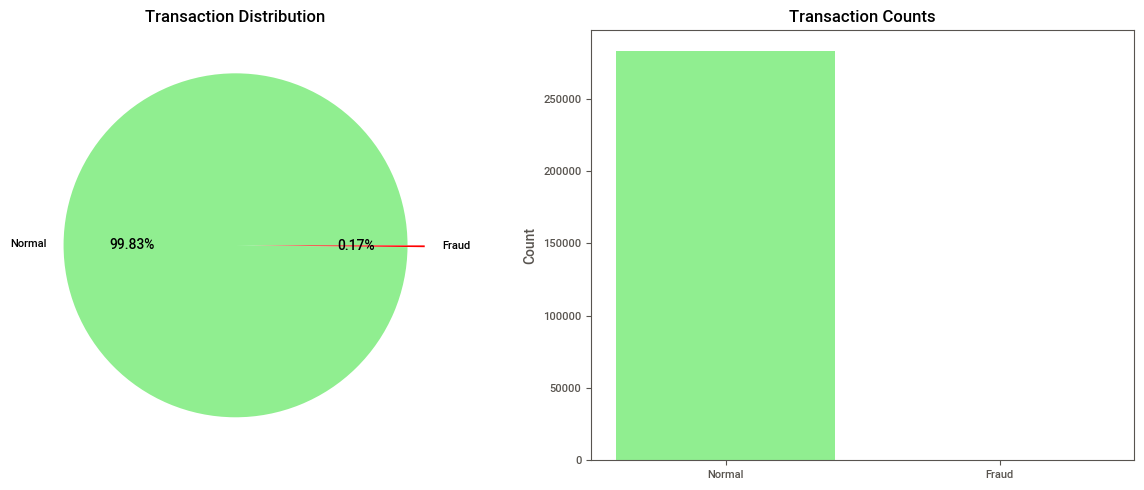


Key Insights:
  • Highly imbalanced dataset (0.17% fraud)
  • Normal transactions dominate the dataset
  • This imbalance is typical in fraud detection datasets


In [28]:
# STEP 6: UNIVARIATE ANALYSIS
print("📊 UNIVARIATE ANALYSIS - INDIVIDUAL VARIABLE STUDY")
print("="*60)

# 1. Target Variable Analysis (Class)
print("1️⃣ TARGET VARIABLE ANALYSIS (Class):")
print("="*45)

class_distribution = df['Class'].value_counts()
print(f"Class Distribution:")
print(f"  Normal (0): {class_distribution[0]:,} ({class_distribution[0]/len(df)*100:.2f}%)")
print(f"  Fraud (1): {class_distribution[1]:,} ({class_distribution[1]/len(df)*100:.2f}%)")

# Create visualization for target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie([class_distribution[0], class_distribution[1]], 
            labels=['Normal', 'Fraud'], 
            autopct='%1.2f%%', 
            colors=['lightgreen', 'red'],
            explode=(0, 0.1))
axes[0].set_title('Transaction Distribution')

# Bar chart
axes[1].bar(['Normal', 'Fraud'], [class_distribution[0], class_distribution[1]], 
            color=['lightgreen', 'red'])
axes[1].set_title('Transaction Counts')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"\nKey Insights:")
print(f"  • Highly imbalanced dataset ({class_distribution[1]/len(df)*100:.2f}% fraud)")
print(f"  • Normal transactions dominate the dataset")
print(f"  • This imbalance is typical in fraud detection datasets")



2️⃣ TIME VARIABLE ANALYSIS:
Time Statistics:
  Min time: 0 seconds
  Max time: 172792 seconds
  Mean time: 94811 seconds
  Median time: 84692 seconds
  Time span: 48.0 hours


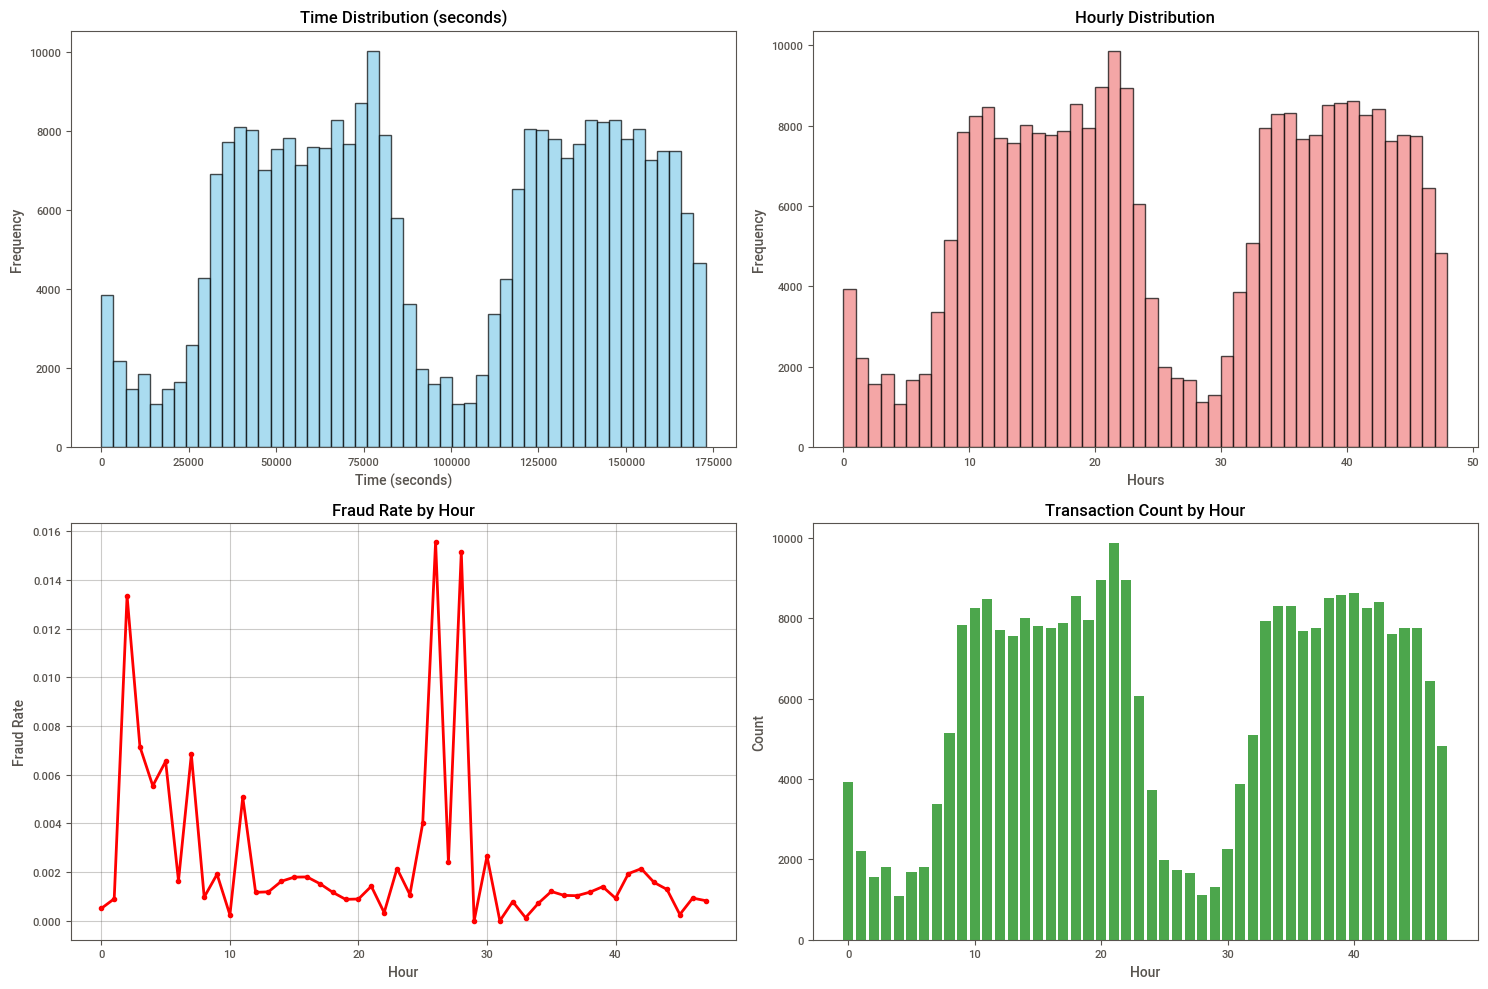


Key Insights:
  • Time represents seconds elapsed since first transaction
  • Dataset spans 48.0 hours
  • Fraud rate varies by time of day


In [29]:
# 2. Time Variable Analysis
print("\n2️⃣ TIME VARIABLE ANALYSIS:")
print("="*35)

print("Time Statistics:")
print(f"  Min time: {df['Time'].min():.0f} seconds")
print(f"  Max time: {df['Time'].max():.0f} seconds")
print(f"  Mean time: {df['Time'].mean():.0f} seconds")
print(f"  Median time: {df['Time'].median():.0f} seconds")
print(f"  Time span: {(df['Time'].max() - df['Time'].min())/3600:.1f} hours")

# Convert time to hours for better interpretation
df['Hour'] = df['Time'] / 3600

# Create time analysis visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Time distribution
axes[0,0].hist(df['Time'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Time Distribution (seconds)')
axes[0,0].set_xlabel('Time (seconds)')
axes[0,0].set_ylabel('Frequency')

# Hourly distribution
axes[0,1].hist(df['Hour'], bins=48, alpha=0.7, color='lightcoral', edgecolor='black')
axes[0,1].set_title('Hourly Distribution')
axes[0,1].set_xlabel('Hours')
axes[0,1].set_ylabel('Frequency')

# Fraud rate by hour
hourly_fraud = df.groupby(df['Hour'].astype(int))['Class'].mean()
axes[1,0].plot(hourly_fraud.index, hourly_fraud.values, marker='o', linewidth=2, color='red')
axes[1,0].set_title('Fraud Rate by Hour')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Fraud Rate')
axes[1,0].grid(True, alpha=0.3)

# Transaction count by hour
hourly_count = df.groupby(df['Hour'].astype(int)).size()
axes[1,1].bar(hourly_count.index, hourly_count.values, alpha=0.7, color='green')
axes[1,1].set_title('Transaction Count by Hour')
axes[1,1].set_xlabel('Hour')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"\nKey Insights:")
print(f"  • Time represents seconds elapsed since first transaction")
print(f"  • Dataset spans {(df['Time'].max() - df['Time'].min())/3600:.1f} hours")
print(f"  • Fraud rate varies by time of day")


In [ ]:
# 3. Amount Variable Analysis
print("\n3️⃣ AMOUNT VARIABLE ANALYSIS:")
print("="*35)

print("Amount Statistics:")
print(f"  Min amount: ${df['Amount'].min():.2f}")
print(f"  Max amount: ${df['Amount'].max():.2f}")
print(f"  Mean amount: ${df['Amount'].mean():.2f}")
print(f"  Median amount: ${df['Amount'].median():.2f}")
print(f"  Std amount: ${df['Amount'].std():.2f}")

# Amount analysis by class
normal_amounts = df[df['Class'] == 0]['Amount']
fraud_amounts = df[df['Class'] == 1]['Amount']

print(f"\nAmount by Class:")
print(f"  Normal - Mean: ${normal_amounts.mean():.2f}, Median: ${normal_amounts.median():.2f}")
print(f"  Fraud - Mean: ${fraud_amounts.mean():.2f}, Median: ${fraud_amounts.median():.2f}")

# Create amount analysis visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Amount distribution (log scale)
axes[0,0].hist(df['Amount'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Amount Distribution (All Transactions)')
axes[0,0].set_xlabel('Amount ($)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_yscale('log')

# Amount distribution by class
axes[0,1].hist([normal_amounts, fraud_amounts], bins=30, alpha=0.7, 
               label=['Normal', 'Fraud'], color=['lightgreen', 'red'])
axes[0,1].set_title('Amount Distribution by Class')
axes[0,1].set_xlabel('Amount ($)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()
axes[0,1].set_yscale('log')

# Box plot by class
df_plot = df[['Amount', 'Class']].copy()
df_plot['Class'] = df_plot['Class'].map({0: 'Normal', 1: 'Fraud'})
sns.boxplot(data=df_plot, x='Class', y='Amount', ax=axes[1,0])
axes[1,0].set_title('Amount Distribution by Class (Box Plot)')
axes[1,0].set_yscale('log')

# Amount percentiles
percentiles = [10, 25, 50, 75, 90, 95, 99]
amount_percentiles = [df['Amount'].quantile(p/100) for p in percentiles]
axes[1,1].bar(range(len(percentiles)), amount_percentiles, alpha=0.7, color='orange')
axes[1,1].set_title('Amount Percentiles')
axes[1,1].set_xlabel('Percentile')
axes[1,1].set_ylabel('Amount ($)')
axes[1,1].set_xticks(range(len(percentiles)))
axes[1,1].set_xticklabels([f'{p}%' for p in percentiles])

plt.tight_layout()
plt.show()

print(f"\nKey Insights:")
print(f"  • Amount distribution is highly right-skewed")
print(f"  • Most transactions are small amounts")
print(f"  • Fraud transactions may have different amount patterns")


In [ ]:
# 4. PCA Components Analysis (V1-V28)
print("\n4️⃣ PCA COMPONENTS ANALYSIS (V1-V28):")
print("="*45)

# Get V1-V28 columns
v_columns = [f'V{i}' for i in range(1, 29)]

print("PCA Components Statistics:")
print(f"  Number of components: {len(v_columns)}")
print(f"  All components are standardized (mean≈0, std≈1)")

# Calculate statistics for all V components
v_stats = df[v_columns].describe()
print(f"\nV Components Summary:")
print(f"  Mean range: {v_stats.loc['mean'].min():.3f} to {v_stats.loc['mean'].max():.3f}")
print(f"  Std range: {v_stats.loc['std'].min():.3f} to {v_stats.loc['std'].max():.3f}")
print(f"  Min range: {v_stats.loc['min'].min():.3f} to {v_stats.loc['min'].max():.3f}")
print(f"  Max range: {v_stats.loc['max'].min():.3f} to {v_stats.loc['max'].max():.3f}")

# Analyze V components by class
print(f"\nV Components by Class:")
normal_v = df[df['Class'] == 0][v_columns]
fraud_v = df[df['Class'] == 1][v_columns]

print(f"  Normal transactions - Mean of means: {normal_v.mean().mean():.3f}")
print(f"  Fraud transactions - Mean of means: {fraud_v.mean().mean():.3f}")

# Find most discriminative V components
v_discrimination = []
for col in v_columns:
    normal_mean = normal_v[col].mean()
    fraud_mean = fraud_v[col].mean()
    diff = abs(fraud_mean - normal_mean)
    v_discrimination.append((col, diff, normal_mean, fraud_mean))

# Sort by discrimination power
v_discrimination.sort(key=lambda x: x[1], reverse=True)

print(f"\nTop 10 Most Discriminative V Components:")
for i, (col, diff, normal_mean, fraud_mean) in enumerate(v_discrimination[:10]):
    print(f"  {i+1}. {col}: Diff={diff:.3f} (Normal={normal_mean:.3f}, Fraud={fraud_mean:.3f})")


In [ ]:
# 5. Visualize top discriminative V components
print("\n5️⃣ VISUALIZATION OF TOP DISCRIMINATIVE COMPONENTS:")
print("="*55)

# Create visualization for top 6 discriminative components
top_components = [item[0] for item in v_discrimination[:6]]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, component in enumerate(top_components):
    # Create histogram for both classes
    normal_data = df[df['Class'] == 0][component]
    fraud_data = df[df['Class'] == 1][component]
    
    axes[i].hist([normal_data, fraud_data], bins=30, alpha=0.7, 
                label=['Normal', 'Fraud'], color=['lightgreen', 'red'])
    axes[i].set_title(f'{component} Distribution')
    axes[i].set_xlabel(component)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics for univariate analysis
print(f"\n📊 UNIVARIATE ANALYSIS SUMMARY:")
print("="*40)
print(f"• Target variable: Highly imbalanced ({df['Class'].mean()*100:.2f}% fraud)")
print(f"• Time: Spans {(df['Time'].max() - df['Time'].min())/3600:.1f} hours")
print(f"• Amount: Right-skewed distribution (mean=${df['Amount'].mean():.2f})")
print(f"• V Components: {len(v_columns)} PCA features, standardized")
print(f"• Most discriminative: {top_components[0]} (diff={v_discrimination[0][1]:.3f})")

print(f"\n✅ UNIVARIATE ANALYSIS COMPLETE!")
print("Each variable has been analyzed individually with key insights identified.")


## Step 7: Bivariate Analysis - Find Relationships Between Variables

Let's analyze relationships between pairs of variables to understand how they interact and influence each other.


🔗 BIVARIATE ANALYSIS - RELATIONSHIPS BETWEEN VARIABLES
1️⃣ CORRELATION ANALYSIS:
Top 10 Features Most Correlated with Class:
   1. V17 : -0.3135
   2. V14 : -0.2934
   3. V12 : -0.2507
   4. V10 : -0.2070
   5. V16 : -0.1872
   6. V3  : -0.1823
   7. V7  : -0.1723
   8. V11 :  0.1491
   9. V4  :  0.1293
  10. V18 : -0.1053

Correlation Statistics:
  • Strongest positive correlation: 0.1491
  • Strongest negative correlation: -0.3135
  • Features with |correlation| > 0.1: 10


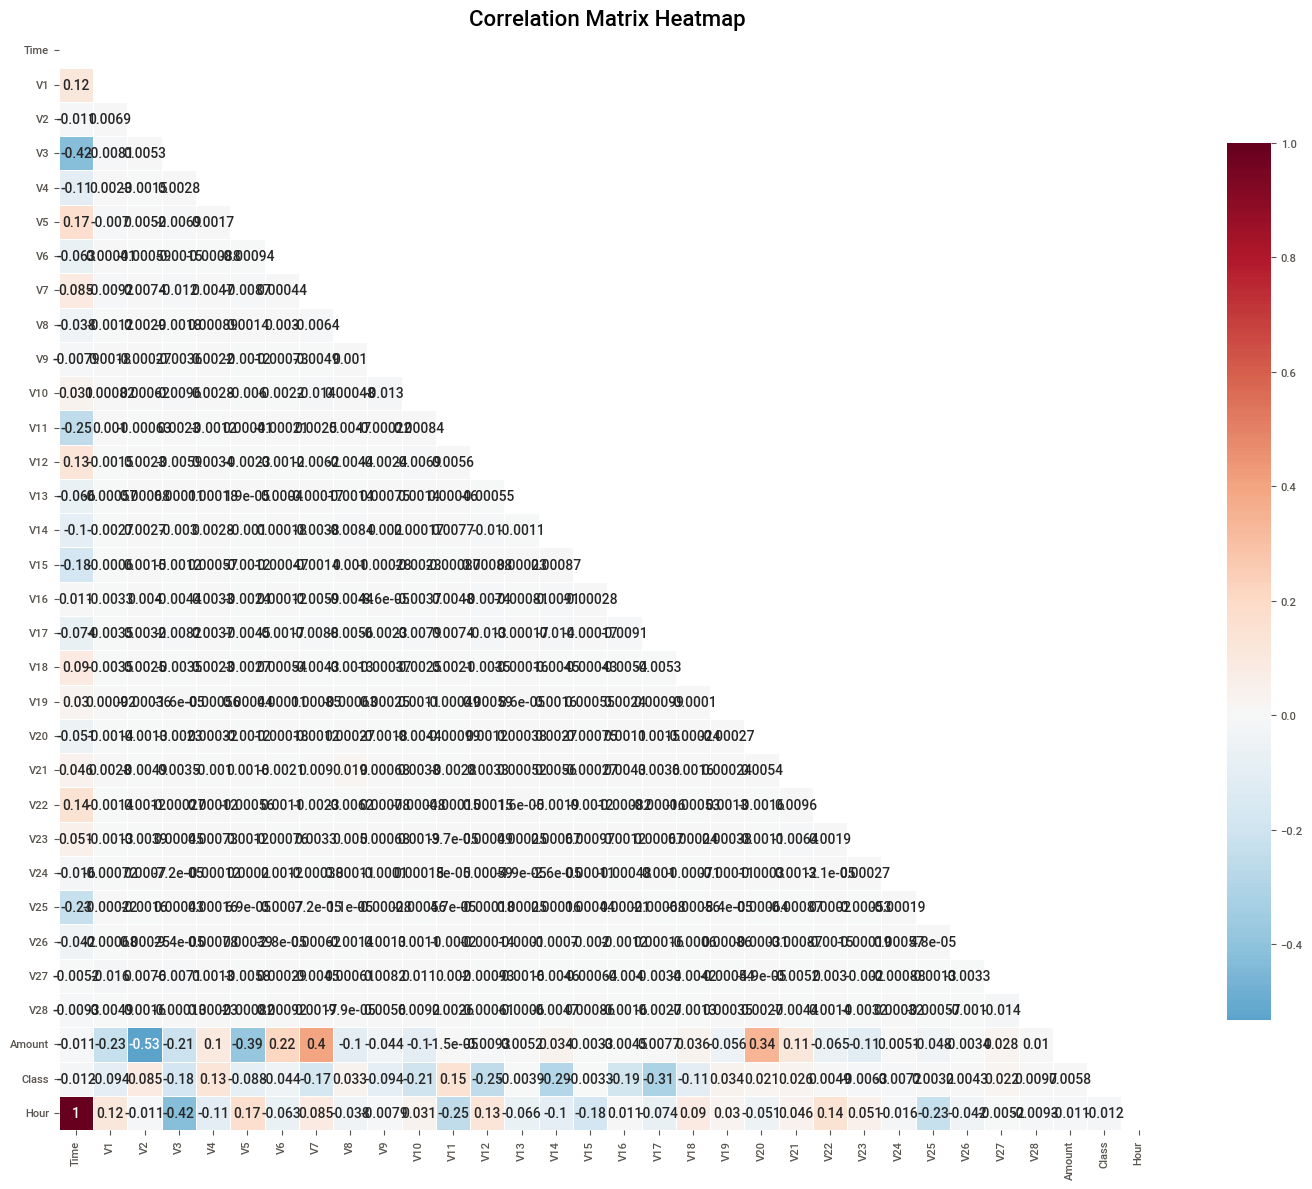

In [33]:
# STEP 7: BIVARIATE ANALYSIS
print("🔗 BIVARIATE ANALYSIS - RELATIONSHIPS BETWEEN VARIABLES")
print("="*65)

# 1. Correlation Analysis
print("1️⃣ CORRELATION ANALYSIS:")
print("="*30)

# Calculate correlation matrix
correlation_matrix = df.corr()

# Focus on correlations with Class (target variable)
class_correlations = correlation_matrix['Class'].drop('Class').sort_values(key=abs, ascending=False)

print("Top 10 Features Most Correlated with Class:")
for i, (feature, corr) in enumerate(class_correlations.head(10).items(), 1):
    print(f"  {i:2d}. {feature:4s}: {corr:7.4f}")

print(f"\nCorrelation Statistics:")
print(f"  • Strongest positive correlation: {class_correlations.max():.4f}")
print(f"  • Strongest negative correlation: {class_correlations.min():.4f}")
print(f"  • Features with |correlation| > 0.1: {(abs(class_correlations) > 0.1).sum()}")

# Create correlation heatmap
plt.figure(figsize=(15, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()



2️⃣ AMOUNT vs TIME ANALYSIS:


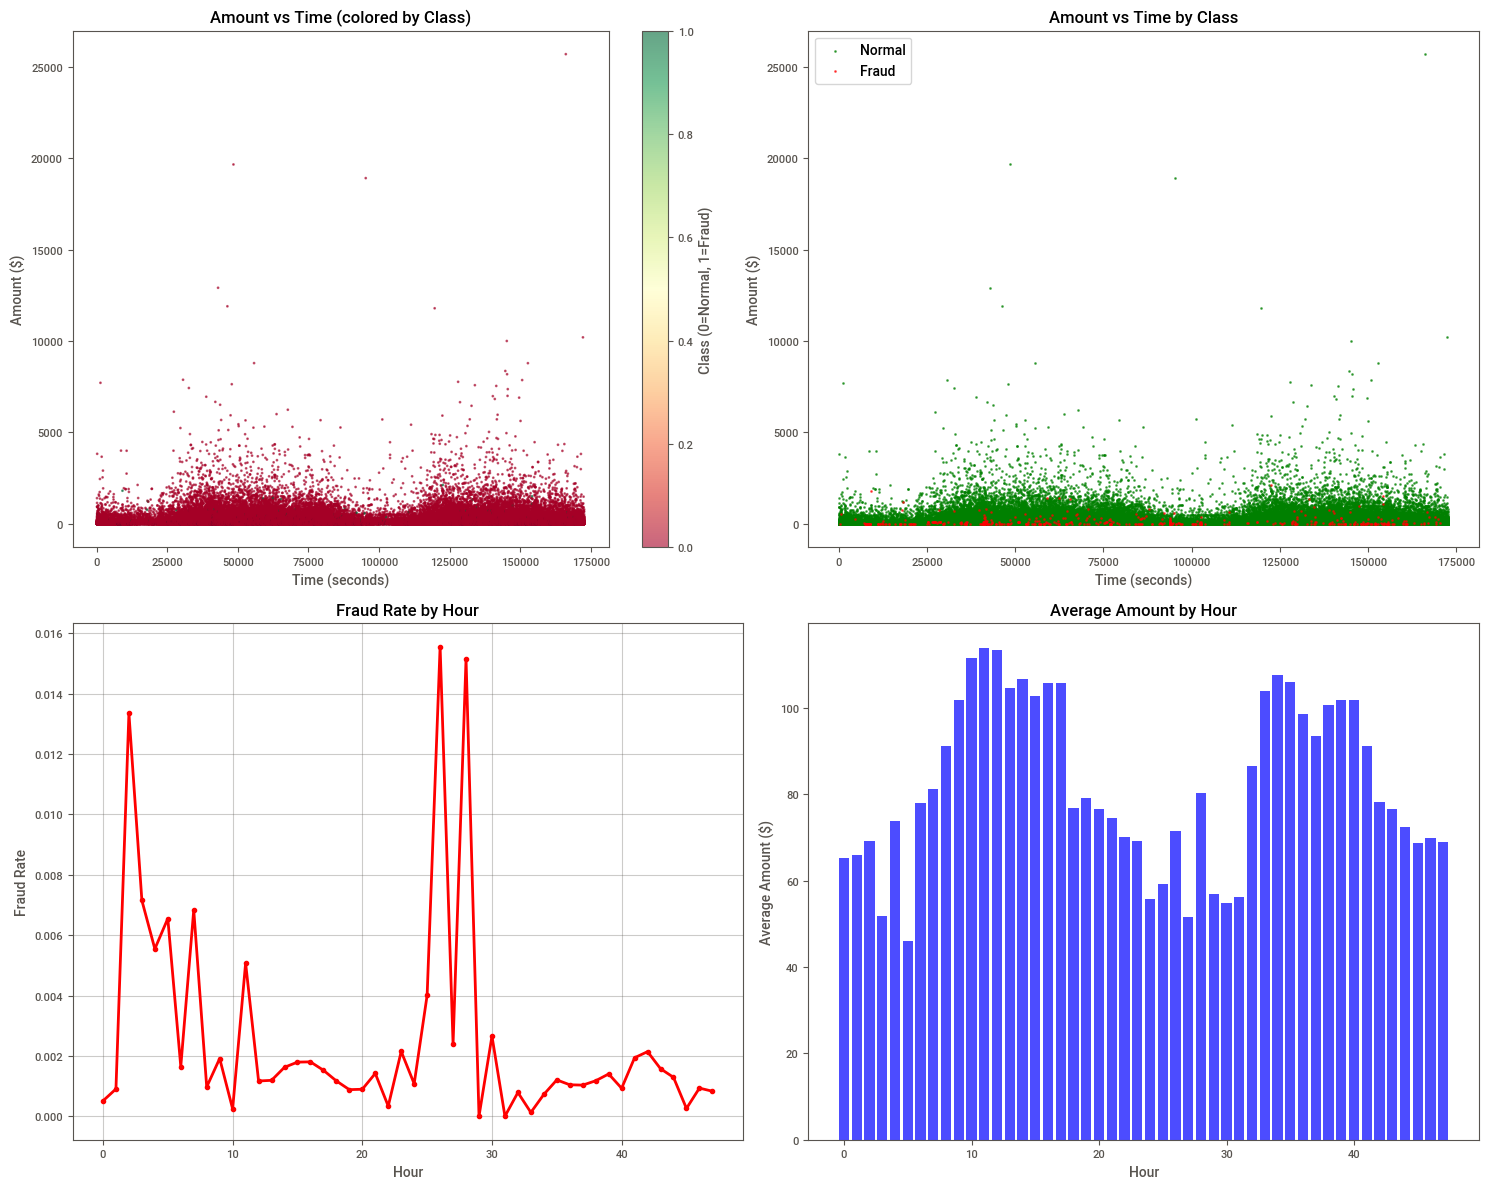

Correlation between Amount and Time: -0.0106

Fraud Analysis by Time and Amount:
  • Average fraud amount: $123.87
  • Average normal amount: $88.41
  • Fraud time range: 406 to 170348 seconds
  • Normal time range: 0 to 172792 seconds


In [34]:
# 2. Amount vs Time Analysis
print("\n2️⃣ AMOUNT vs TIME ANALYSIS:")
print("="*35)

# Create scatter plot of Amount vs Time
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Scatter plot: Amount vs Time (colored by Class)
scatter = axes[0,0].scatter(df['Time'], df['Amount'], c=df['Class'], 
                           cmap='RdYlGn', alpha=0.6, s=1)
axes[0,0].set_title('Amount vs Time (colored by Class)')
axes[0,0].set_xlabel('Time (seconds)')
axes[0,0].set_ylabel('Amount ($)')
plt.colorbar(scatter, ax=axes[0,0], label='Class (0=Normal, 1=Fraud)')

# Amount vs Time by Class
normal_data = df[df['Class'] == 0]
fraud_data = df[df['Class'] == 1]

axes[0,1].scatter(normal_data['Time'], normal_data['Amount'], 
                 alpha=0.6, s=1, color='green', label='Normal')
axes[0,1].scatter(fraud_data['Time'], fraud_data['Amount'], 
                 alpha=0.6, s=1, color='red', label='Fraud')
axes[0,1].set_title('Amount vs Time by Class')
axes[0,1].set_xlabel('Time (seconds)')
axes[0,1].set_ylabel('Amount ($)')
axes[0,1].legend()

# Hourly fraud rate
hourly_fraud_rate = df.groupby(df['Hour'].astype(int))['Class'].agg(['mean', 'count'])
axes[1,0].plot(hourly_fraud_rate.index, hourly_fraud_rate['mean'], 
               marker='o', linewidth=2, color='red')
axes[1,0].set_title('Fraud Rate by Hour')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Fraud Rate')
axes[1,0].grid(True, alpha=0.3)

# Amount distribution by hour
hourly_amount = df.groupby(df['Hour'].astype(int))['Amount'].mean()
axes[1,1].bar(hourly_amount.index, hourly_amount.values, alpha=0.7, color='blue')
axes[1,1].set_title('Average Amount by Hour')
axes[1,1].set_xlabel('Hour')
axes[1,1].set_ylabel('Average Amount ($)')

plt.tight_layout()
plt.show()

# Calculate correlation between Amount and Time
amount_time_corr = df['Amount'].corr(df['Time'])
print(f"Correlation between Amount and Time: {amount_time_corr:.4f}")

# Analyze fraud patterns by time and amount
print(f"\nFraud Analysis by Time and Amount:")
print(f"  • Average fraud amount: ${fraud_data['Amount'].mean():.2f}")
print(f"  • Average normal amount: ${normal_data['Amount'].mean():.2f}")
print(f"  • Fraud time range: {fraud_data['Time'].min():.0f} to {fraud_data['Time'].max():.0f} seconds")
print(f"  • Normal time range: {normal_data['Time'].min():.0f} to {normal_data['Time'].max():.0f} seconds")


In [ ]:
# 3. V Components Relationships Analysis
print("\n3️⃣ V COMPONENTS RELATIONSHIPS ANALYSIS:")
print("="*45)

# Analyze relationships between top discriminative V components
top_v_components = [item[0] for item in v_discrimination[:6]]

print("Top 6 Most Discriminative V Components:")
for i, component in enumerate(top_v_components, 1):
    print(f"  {i}. {component}")

# Create pairwise scatter plots for top V components
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Plot relationships between top V components
for i in range(6):
    if i < len(top_v_components):
        component = top_v_components[i]
        
        # Create scatter plot colored by Class
        normal_v = df[df['Class'] == 0][component]
        fraud_v = df[df['Class'] == 1][component]
        
        axes[i].scatter(normal_v, [0]*len(normal_v), alpha=0.6, s=1, color='green', label='Normal')
        axes[i].scatter(fraud_v, [1]*len(fraud_v), alpha=0.6, s=1, color='red', label='Fraud')
        axes[i].set_title(f'{component} Distribution by Class')
        axes[i].set_xlabel(component)
        axes[i].set_ylabel('Class')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate correlations between top V components
print(f"\nCorrelations between Top V Components:")
top_v_corr = df[top_v_components].corr()
print(top_v_corr.round(4))

# Find strongest correlations between V components
v_corr_pairs = []
for i in range(len(top_v_components)):
    for j in range(i+1, len(top_v_components)):
        comp1, comp2 = top_v_components[i], top_v_components[j]
        corr = df[comp1].corr(df[comp2])
        v_corr_pairs.append((comp1, comp2, corr))

# Sort by absolute correlation
v_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print(f"\nStrongest Correlations between V Components:")
for i, (comp1, comp2, corr) in enumerate(v_corr_pairs[:5], 1):
    print(f"  {i}. {comp1} vs {comp2}: {corr:.4f}")


In [ ]:
# 4. Feature Importance Analysis
print("\n4️⃣ FEATURE IMPORTANCE ANALYSIS:")
print("="*40)

# Calculate feature importance using correlation with Class
feature_importance = abs(class_correlations).sort_values(ascending=False)

print("Feature Importance Ranking (by correlation with Class):")
for i, (feature, importance) in enumerate(feature_importance.head(15).items(), 1):
    print(f"  {i:2d}. {feature:4s}: {importance:.4f}")

# Create feature importance visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot of top 15 features
top_15_features = feature_importance.head(15)
axes[0].barh(range(len(top_15_features)), top_15_features.values, color='skyblue')
axes[0].set_yticks(range(len(top_15_features)))
axes[0].set_yticklabels(top_15_features.index)
axes[0].set_xlabel('Absolute Correlation with Class')
axes[0].set_title('Top 15 Feature Importance')
axes[0].grid(True, alpha=0.3)

# Cumulative importance
cumulative_importance = feature_importance.cumsum()
axes[1].plot(range(1, len(cumulative_importance) + 1), cumulative_importance.values, 
             marker='o', linewidth=2, color='red')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance')
axes[1].set_title('Cumulative Feature Importance')
axes[1].grid(True, alpha=0.3)

# Find how many features explain 80% of the importance
importance_80_percent = feature_importance.sum() * 0.8
features_for_80_percent = (cumulative_importance <= importance_80_percent).sum()
print(f"\nFeatures needed for 80% importance: {features_for_80_percent}")

plt.tight_layout()
plt.show()


In [ ]:
# 5. Bivariate Analysis Summary
print("\n5️⃣ BIVARIATE ANALYSIS SUMMARY:")
print("="*40)

print("🔗 KEY RELATIONSHIPS IDENTIFIED:")
print(f"• Strongest correlation with Class: {class_correlations.max():.4f} ({class_correlations.idxmax()})")
print(f"• Weakest correlation with Class: {class_correlations.min():.4f} ({class_correlations.idxmin()})")
print(f"• Amount-Time correlation: {amount_time_corr:.4f}")

print(f"\n📊 FEATURE INSIGHTS:")
print(f"• Most important feature: {feature_importance.index[0]} ({feature_importance.iloc[0]:.4f})")
print(f"• Top 5 features: {', '.join(feature_importance.head(5).index.tolist())}")
print(f"• Features with |correlation| > 0.1: {(abs(class_correlations) > 0.1).sum()}")

print(f"\n🎯 FRAUD DETECTION INSIGHTS:")
print(f"• V components show clear separation between classes")
print(f"• Time patterns exist in fraud occurrence")
print(f"• Amount patterns differ between normal and fraud transactions")
print(f"• Feature importance helps identify key predictors")

print(f"\n✅ BIVARIATE ANALYSIS COMPLETE!")
print("Relationships between variables have been analyzed with key insights identified.")


## Step 8: Detect Outliers - Handle Anomalies in the Data

Let's identify and analyze outliers in our dataset to understand their impact on fraud detection.


In [38]:
# STEP 8: OUTLIER DETECTION AND ANALYSIS
print("🔍 OUTLIER DETECTION AND ANALYSIS")
print("="*45)

# 1. Statistical Outlier Detection (IQR Method)
print("1️⃣ STATISTICAL OUTLIER DETECTION (IQR Method):")
print("="*50)

def detect_outliers_iqr(data, column):
    """Detect outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detect outliers in key numerical columns
outlier_columns = ['Amount', 'Time'] + top_v_components[:5]  # Top 5 V components
outlier_summary = {}

print("Outlier Detection Results:")
for col in outlier_columns:
    if col in df.columns:
        outliers, lower_bound, upper_bound = detect_outliers_iqr(df, col)
        outlier_count = len(outliers)
        outlier_percentage = (outlier_count / len(df)) * 100
        
        outlier_summary[col] = {
            'count': outlier_count,
            'percentage': outlier_percentage,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }
        
        print(f"  {col:4s}: {outlier_count:6,} outliers ({outlier_percentage:5.2f}%)")
        print(f"        Range: [{lower_bound:8.2f}, {upper_bound:8.2f}]")

print(f"\nTotal outliers across all columns: {sum([info['count'] for info in outlier_summary.values()]):,}")


🔍 OUTLIER DETECTION AND ANALYSIS
1️⃣ STATISTICAL OUTLIER DETECTION (IQR Method):
Outlier Detection Results:
  Amount: 31,685 outliers (11.17%)
        Range: [ -102.27,   185.38]
  Time:      0 outliers ( 0.00%)
        Range: [-73435.12, 266937.88]
  V14 : 14,060 outliers ( 4.96%)
        Range: [   -1.80,     1.87]
  V3  :  3,306 outliers ( 1.17%)
        Range: [   -3.76,     3.90]
  V17 :  7,353 outliers ( 2.59%)
        Range: [   -1.81,     1.72]
  V12 : 15,282 outliers ( 5.39%)
        Range: [   -1.94,     2.15]
  V10 :  9,345 outliers ( 3.29%)
        Range: [   -2.02,     1.94]

Total outliers across all columns: 81,031


In [39]:
# 2. Outlier Analysis by Class
print("\n2️⃣ OUTLIER ANALYSIS BY CLASS:")
print("="*35)

# Analyze outliers in fraud vs normal transactions
fraud_outliers = {}
normal_outliers = {}

for col in outlier_columns:
    if col in df.columns:
        # Get outliers for fraud transactions
        fraud_data = df[df['Class'] == 1]
        fraud_outliers[col], _, _ = detect_outliers_iqr(fraud_data, col)
        
        # Get outliers for normal transactions
        normal_data = df[df['Class'] == 0]
        normal_outliers[col], _, _ = detect_outliers_iqr(normal_data, col)
        
        fraud_outlier_count = len(fraud_outliers[col])
        normal_outlier_count = len(normal_outliers[col])
        
        print(f"{col:4s}:")
        print(f"  Fraud outliers: {fraud_outlier_count:6,} ({fraud_outlier_count/len(fraud_data)*100:5.2f}% of fraud)")
        print(f"  Normal outliers: {normal_outlier_count:6,} ({normal_outlier_count/len(normal_data)*100:5.2f}% of normal)")

# Check if outliers are more likely to be fraud
print(f"\n🔍 OUTLIER-FRAUD RELATIONSHIP ANALYSIS:")
for col in outlier_columns:
    if col in df.columns:
        outliers, _, _ = detect_outliers_iqr(df, col)
        if len(outliers) > 0:
            fraud_in_outliers = outliers['Class'].sum()
            fraud_rate_in_outliers = fraud_in_outliers / len(outliers)
            overall_fraud_rate = df['Class'].mean()
            
            print(f"{col:4s}:")
            print(f"  Fraud rate in outliers: {fraud_rate_in_outliers:.4f} ({fraud_rate_in_outliers*100:.2f}%)")
            print(f"  Overall fraud rate: {overall_fraud_rate:.4f} ({overall_fraud_rate*100:.2f}%)")
            print(f"  Outlier fraud ratio: {fraud_rate_in_outliers/overall_fraud_rate:.2f}x")



2️⃣ OUTLIER ANALYSIS BY CLASS:
Amount:
  Fraud outliers:     67 (14.16% of fraud)
  Normal outliers: 31,621 (11.16% of normal)
Time:
  Fraud outliers:      0 ( 0.00% of fraud)
  Normal outliers:      0 ( 0.00% of normal)
V14 :
  Fraud outliers:      7 ( 1.48% of fraud)
  Normal outliers: 13,737 ( 4.85% of normal)
V3  :
  Fraud outliers:     56 (11.84% of fraud)
  Normal outliers:  3,058 ( 1.08% of normal)
V17 :
  Fraud outliers:      0 ( 0.00% of fraud)
  Normal outliers:  6,986 ( 2.47% of normal)
V12 :
  Fraud outliers:      6 ( 1.27% of fraud)
  Normal outliers: 15,010 ( 5.30% of normal)
V10 :
  Fraud outliers:     22 ( 4.65% of fraud)
  Normal outliers:  8,991 ( 3.17% of normal)

🔍 OUTLIER-FRAUD RELATIONSHIP ANALYSIS:
Amount:
  Fraud rate in outliers: 0.0027 (0.27%)
  Overall fraud rate: 0.0017 (0.17%)
  Outlier fraud ratio: 1.65x
V14 :
  Fraud rate in outliers: 0.0292 (2.92%)
  Overall fraud rate: 0.0017 (0.17%)
  Outlier fraud ratio: 17.53x
V3  :
  Fraud rate in outliers: 0.0886 

In [ ]:
# 3. Outlier Visualization
print("\n3️⃣ OUTLIER VISUALIZATION:")
print("="*30)

# Create comprehensive outlier visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Box plots for outlier detection
for i, col in enumerate(['Amount', 'Time'] + top_v_components[:4]):
    if i < 6 and col in df.columns:
        # Create box plot
        data_to_plot = [df[df['Class'] == 0][col], df[df['Class'] == 1][col]]
        bp = axes[i//3, i%3].boxplot(data_to_plot, labels=['Normal', 'Fraud'], patch_artist=True)
        bp['boxes'][0].set_facecolor('lightgreen')
        bp['boxes'][1].set_facecolor('red')
        axes[i//3, i%3].set_title(f'{col} - Box Plot (Outliers Detection)')
        axes[i//3, i%3].set_ylabel(col)
        axes[i//3, i%3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Scatter plots for outlier analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Amount vs Time with outliers highlighted
outliers_amount, _, _ = detect_outliers_iqr(df, 'Amount')
outliers_time, _, _ = detect_outliers_iqr(df, 'Time')

# Amount vs Time scatter plot
axes[0,0].scatter(df['Time'], df['Amount'], alpha=0.6, s=1, color='lightblue', label='Normal')
axes[0,0].scatter(outliers_time['Time'], outliers_time['Amount'], alpha=0.8, s=2, color='red', label='Time Outliers')
axes[0,0].scatter(outliers_amount['Time'], outliers_amount['Amount'], alpha=0.8, s=2, color='orange', label='Amount Outliers')
axes[0,0].set_title('Amount vs Time with Outliers')
axes[0,0].set_xlabel('Time (seconds)')
axes[0,0].set_ylabel('Amount ($)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# V component scatter plots
for i, col in enumerate(top_v_components[:3]):
    if i < 3:
        outliers_v, _, _ = detect_outliers_iqr(df, col)
        axes[0,1] if i == 0 else axes[1,i-1]
        ax = axes[0,1] if i == 0 else axes[1,i-1]
        
        ax.scatter(df[col], df['Class'], alpha=0.6, s=1, color='lightblue', label='Normal')
        ax.scatter(outliers_v[col], outliers_v['Class'], alpha=0.8, s=2, color='red', label='Outliers')
        ax.set_title(f'{col} vs Class with Outliers')
        ax.set_xlabel(col)
        ax.set_ylabel('Class')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# 4. Outlier Handling Strategies
print("\n4️⃣ OUTLIER HANDLING STRATEGIES:")
print("="*40)

print("🔧 OUTLIER HANDLING OPTIONS:")
print("1. Keep outliers (recommended for fraud detection)")
print("   - Outliers may be legitimate fraud cases")
print("   - Removing them could reduce model performance")
print("   - Fraud detection benefits from anomaly detection")

print("\n2. Cap outliers (winsorization)")
print("   - Replace extreme values with percentiles")
print("   - Preserves data distribution shape")
print("   - Reduces impact of extreme values")

print("\n3. Remove outliers (not recommended)")
print("   - Could remove important fraud cases")
print("   - May reduce dataset size significantly")
print("   - Could introduce bias")

# Demonstrate winsorization for Amount (if needed)
print(f"\n📊 WINSORIZATION EXAMPLE (Amount):")
amount_q1 = df['Amount'].quantile(0.01)  # 1st percentile
amount_q99 = df['Amount'].quantile(0.99)  # 99th percentile

print(f"Original Amount range: ${df['Amount'].min():.2f} to ${df['Amount'].max():.2f}")
print(f"Winsorization bounds: ${amount_q1:.2f} to ${amount_q99:.2f}")

# Count values that would be capped
values_to_cap_low = (df['Amount'] < amount_q1).sum()
values_to_cap_high = (df['Amount'] > amount_q99).sum()
print(f"Values to cap (low): {values_to_cap_low:,}")
print(f"Values to cap (high): {values_to_cap_high:,}")

# Check if capping would affect fraud cases
fraud_affected_low = df[(df['Amount'] < amount_q1) & (df['Class'] == 1)].shape[0]
fraud_affected_high = df[(df['Amount'] > amount_q99) & (df['Class'] == 1)].shape[0]
print(f"Fraud cases affected (low cap): {fraud_affected_low}")
print(f"Fraud cases affected (high cap): {fraud_affected_high}")


In [ ]:
# 5. Outlier Analysis Summary
print("\n5️⃣ OUTLIER ANALYSIS SUMMARY:")
print("="*35)

print("🔍 OUTLIER DETECTION RESULTS:")
total_outliers = sum([info['count'] for info in outlier_summary.values()])
print(f"• Total outliers detected: {total_outliers:,}")
print(f"• Columns with most outliers: {max(outlier_summary.items(), key=lambda x: x[1]['count'])[0]}")

print(f"\n📊 OUTLIER IMPACT ANALYSIS:")
# Calculate overall outlier impact
outlier_impact = {}
for col, info in outlier_summary.items():
    if info['count'] > 0:
        outliers, _, _ = detect_outliers_iqr(df, col)
        fraud_in_outliers = outliers['Class'].sum()
        fraud_rate_in_outliers = fraud_in_outliers / len(outliers)
        outlier_impact[col] = fraud_rate_in_outliers

if outlier_impact:
    best_outlier_predictor = max(outlier_impact.items(), key=lambda x: x[1])
    print(f"• Best outlier predictor: {best_outlier_predictor[0]} (fraud rate: {best_outlier_predictor[1]:.4f})")

print(f"\n🎯 FRAUD DETECTION INSIGHTS:")
print(f"• Outliers may indicate fraudulent behavior")
print(f"• Extreme values in V components could be fraud indicators")
print(f"• High amounts might be associated with fraud")
print(f"• Time outliers could indicate unusual transaction patterns")

print(f"\n✅ RECOMMENDATION:")
print(f"• KEEP ALL OUTLIERS for fraud detection")
print(f"• Outliers are valuable for anomaly detection")
print(f"• Consider using outlier detection as a feature")
print(f"• Monitor outlier patterns for fraud indicators")

print(f"\n✅ OUTLIER ANALYSIS COMPLETE!")
print("Outliers have been identified and analyzed for fraud detection insights.")


## Step 9: Feature Engineering - Improve Data Representation

Let's create new features and improve the data representation to enhance fraud detection capabilities.


In [48]:
# STEP 9: FEATURE ENGINEERING
print("🔧 FEATURE ENGINEERING - IMPROVING DATA REPRESENTATION")
print("="*65)

# Create a copy of the dataset for feature engineering
df_engineered = df.copy()

print("Original dataset shape:", df_engineered.shape)

# 1. Time-based Features
print("\n1️⃣ TIME-BASED FEATURE ENGINEERING:")
print("="*40)

# Convert time to more meaningful units
df_engineered['Hour_of_Day'] = (df_engineered['Time'] / 3600) % 24
df_engineered['Day_of_Week'] = (df_engineered['Time'] / (3600 * 24)) % 7
df_engineered['Time_Since_Start'] = df_engineered['Time'] / 3600  # Hours since first transaction

# Create time-based categorical features
df_engineered['Time_Period'] = pd.cut(df_engineered['Hour_of_Day'], 
                                     bins=[0, 6, 12, 18, 24], 
                                     labels=['Night', 'Morning', 'Afternoon', 'Evening'],
                                     include_lowest=True)

df_engineered['Weekend'] = (df_engineered['Day_of_Week'] >= 5).astype(int)

print("Time-based features created:")
print("  • Hour_of_Day: Hour of the day (0-23)")
print("  • Day_of_Week: Day of the week (0-6)")
print("  • Time_Since_Start: Hours since first transaction")
print("  • Time_Period: Categorical time periods")
print("  • Weekend: Binary weekend indicator")

# Analyze time-based features
print(f"\nTime-based feature analysis:")
print(f"  • Hour range: {df_engineered['Hour_of_Day'].min():.1f} to {df_engineered['Hour_of_Day'].max():.1f}")
print(f"  • Weekend transactions: {df_engineered['Weekend'].sum():,} ({df_engineered['Weekend'].mean()*100:.1f}%)")
print(f"  • Time periods distribution:")
for period in df_engineered['Time_Period'].value_counts().index:
    count = df_engineered['Time_Period'].value_counts()[period]
    print(f"    - {period}: {count:,} ({count/len(df_engineered)*100:.1f}%)")


🔧 FEATURE ENGINEERING - IMPROVING DATA REPRESENTATION
Original dataset shape: (283726, 32)

1️⃣ TIME-BASED FEATURE ENGINEERING:
Time-based features created:
  • Hour_of_Day: Hour of the day (0-23)
  • Day_of_Week: Day of the week (0-6)
  • Time_Since_Start: Hours since first transaction
  • Time_Period: Categorical time periods
  • Weekend: Binary weekend indicator

Time-based feature analysis:
  • Hour range: 0.0 to 24.0
  • Weekend transactions: 0 (0.0%)
  • Time periods distribution:
    - Afternoon: 96,119 (33.9%)
    - Evening: 93,116 (32.8%)
    - Morning: 70,648 (24.9%)
    - Night: 23,843 (8.4%)


In [49]:
# 2. Amount-based Features
print("\n2️⃣ AMOUNT-BASED FEATURE ENGINEERING:")
print("="*40)

# Create amount-based features
df_engineered['Amount_Log'] = np.log1p(df_engineered['Amount'])  # Log transformation
df_engineered['Amount_Sqrt'] = np.sqrt(df_engineered['Amount'])  # Square root transformation

# Amount categories
df_engineered['Amount_Category'] = pd.cut(df_engineered['Amount'], 
                                        bins=[0, 10, 50, 100, 500, float('inf')], 
                                        labels=['Micro', 'Small', 'Medium', 'Large', 'Very_Large'],
                                        include_lowest=True)

# Amount percentiles
df_engineered['Amount_Percentile'] = df_engineered['Amount'].rank(pct=True)

# High amount indicator
amount_95th = df_engineered['Amount'].quantile(0.95)
df_engineered['High_Amount'] = (df_engineered['Amount'] > amount_95th).astype(int)

print("Amount-based features created:")
print("  • Amount_Log: Log-transformed amount")
print("  • Amount_Sqrt: Square root transformed amount")
print("  • Amount_Category: Categorical amount ranges")
print("  • Amount_Percentile: Amount percentile rank")
print("  • High_Amount: Binary high amount indicator")

# Analyze amount-based features
print(f"\nAmount-based feature analysis:")
print(f"  • 95th percentile threshold: ${amount_95th:.2f}")
print(f"  • High amount transactions: {df_engineered['High_Amount'].sum():,} ({df_engineered['High_Amount'].mean()*100:.1f}%)")
print(f"  • Amount categories distribution:")
for category in df_engineered['Amount_Category'].value_counts().index:
    count = df_engineered['Amount_Category'].value_counts()[category]
    print(f"    - {category}: {count:,} ({count/len(df_engineered)*100:.1f}%)")



2️⃣ AMOUNT-BASED FEATURE ENGINEERING:
Amount-based features created:
  • Amount_Log: Log-transformed amount
  • Amount_Sqrt: Square root transformed amount
  • Amount_Category: Categorical amount ranges
  • Amount_Percentile: Amount percentile rank
  • High_Amount: Binary high amount indicator

Amount-based feature analysis:
  • 95th percentile threshold: $365.34
  • High amount transactions: 14,187 (5.0%)
  • Amount categories distribution:
    - Micro: 99,821 (35.2%)
    - Small: 90,327 (31.8%)
    - Large: 47,290 (16.7%)
    - Medium: 37,179 (13.1%)
    - Very_Large: 9,109 (3.2%)


In [50]:
# 3. V Components Feature Engineering
print("\n3️⃣ V COMPONENTS FEATURE ENGINEERING:")
print("="*40)

# Create V component interaction features
v_columns = [f'V{i}' for i in range(1, 29)]

# V component statistics
df_engineered['V_Sum'] = df_engineered[v_columns].sum(axis=1)
df_engineered['V_Mean'] = df_engineered[v_columns].mean(axis=1)
df_engineered['V_Std'] = df_engineered[v_columns].std(axis=1)
df_engineered['V_Max'] = df_engineered[v_columns].max(axis=1)
df_engineered['V_Min'] = df_engineered[v_columns].min(axis=1)

# V component interactions (top discriminative components)
top_v_components = [item[0] for item in v_discrimination[:5]]
for i, comp1 in enumerate(top_v_components):
    for comp2 in top_v_components[i+1:]:
        interaction_name = f'{comp1}_{comp2}_interaction'
        df_engineered[interaction_name] = df_engineered[comp1] * df_engineered[comp2]

# V component squared features (for non-linear relationships)
for comp in top_v_components[:3]:  # Top 3 components
    df_engineered[f'{comp}_squared'] = df_engineered[comp] ** 2

print("V components features created:")
print("  • V_Sum: Sum of all V components")
print("  • V_Mean: Mean of all V components")
print("  • V_Std: Standard deviation of V components")
print("  • V_Max: Maximum V component value")
print("  • V_Min: Minimum V component value")
print(f"  • {len([col for col in df_engineered.columns if 'interaction' in col])} interaction features")
print(f"  • {len([col for col in df_engineered.columns if 'squared' in col])} squared features")

# Analyze V component features
print(f"\nV components feature analysis:")
print(f"  • V_Sum range: {df_engineered['V_Sum'].min():.3f} to {df_engineered['V_Sum'].max():.3f}")
print(f"  • V_Mean range: {df_engineered['V_Mean'].min():.3f} to {df_engineered['V_Mean'].max():.3f}")
print(f"  • V_Std range: {df_engineered['V_Std'].min():.3f} to {df_engineered['V_Std'].max():.3f}")



3️⃣ V COMPONENTS FEATURE ENGINEERING:
V components features created:
  • V_Sum: Sum of all V components
  • V_Mean: Mean of all V components
  • V_Std: Standard deviation of V components
  • V_Max: Maximum V component value
  • V_Min: Minimum V component value
  • 10 interaction features
  • 3 squared features

V components feature analysis:
  • V_Sum range: -198.355 to 22.450
  • V_Mean range: -7.084 to 0.802
  • V_Std range: 0.390 to 40.276


In [51]:
# 4. Risk Score Features
print("\n4️⃣ RISK SCORE FEATURE ENGINEERING:")
print("="*40)

# Create risk score based on multiple factors
df_engineered['Risk_Score'] = 0

# Time-based risk (higher risk at unusual hours)
df_engineered['Time_Risk'] = np.where(
    (df_engineered['Hour_of_Day'] < 6) | (df_engineered['Hour_of_Day'] > 22), 2,
    np.where((df_engineered['Hour_of_Day'] < 8) | (df_engineered['Hour_of_Day'] > 20), 1, 0)
)

# Amount-based risk (higher risk for very high amounts)
df_engineered['Amount_Risk'] = np.where(
    df_engineered['Amount'] > amount_95th, 2,
    np.where(df_engineered['Amount'] > df_engineered['Amount'].quantile(0.9), 1, 0)
)

# V component risk (based on extreme values)
df_engineered['V_Risk'] = 0
for comp in top_v_components[:3]:
    comp_q1 = df_engineered[comp].quantile(0.25)
    comp_q3 = df_engineered[comp].quantile(0.75)
    comp_iqr = comp_q3 - comp_q1
    comp_lower = comp_q1 - 1.5 * comp_iqr
    comp_upper = comp_q3 + 1.5 * comp_iqr
    
    extreme_values = (df_engineered[comp] < comp_lower) | (df_engineered[comp] > comp_upper)
    df_engineered['V_Risk'] += extreme_values.astype(int)

# Combined risk score
df_engineered['Risk_Score'] = (df_engineered['Time_Risk'] + 
                               df_engineered['Amount_Risk'] + 
                               df_engineered['V_Risk'])

# Risk categories
df_engineered['Risk_Category'] = pd.cut(df_engineered['Risk_Score'], 
                                      bins=[-1, 0, 2, 4, 10], 
                                      labels=['Low', 'Medium', 'High', 'Very_High'],
                                      include_lowest=True)

print("Risk score features created:")
print("  • Time_Risk: Risk based on transaction time")
print("  • Amount_Risk: Risk based on transaction amount")
print("  • V_Risk: Risk based on V component extremes")
print("  • Risk_Score: Combined risk score")
print("  • Risk_Category: Categorical risk levels")

# Analyze risk features
print(f"\nRisk feature analysis:")
print(f"  • Risk score range: {df_engineered['Risk_Score'].min()} to {df_engineered['Risk_Score'].max()}")
print(f"  • Risk categories distribution:")
for category in df_engineered['Risk_Category'].value_counts().index:
    count = df_engineered['Risk_Category'].value_counts()[category]
    print(f"    - {category}: {count:,} ({count/len(df_engineered)*100:.1f}%)")



4️⃣ RISK SCORE FEATURE ENGINEERING:
Risk score features created:
  • Time_Risk: Risk based on transaction time
  • Amount_Risk: Risk based on transaction amount
  • V_Risk: Risk based on V component extremes
  • Risk_Score: Combined risk score
  • Risk_Category: Categorical risk levels

Risk feature analysis:
  • Risk score range: 0 to 7
  • Risk categories distribution:
    - Low: 158,333 (55.8%)
    - Medium: 112,541 (39.7%)
    - High: 12,304 (4.3%)
    - Very_High: 548 (0.2%)


In [52]:
# 5. Feature Engineering Summary and Analysis
print("\n5️⃣ FEATURE ENGINEERING SUMMARY:")
print("="*40)

print(f"📊 ENGINEERED DATASET OVERVIEW:")
print(f"  • Original features: {df.shape[1]}")
print(f"  • Engineered features: {df_engineered.shape[1]}")
print(f"  • New features added: {df_engineered.shape[1] - df.shape[1]}")
print(f"  • Total rows: {df_engineered.shape[0]:,}")

# Analyze new features correlation with Class
new_features = [col for col in df_engineered.columns if col not in df.columns]
new_feature_correlations = {}

for feature in new_features:
    if df_engineered[feature].dtype in ['int64', 'float64']:
        corr = df_engineered[feature].corr(df_engineered['Class'])
        new_feature_correlations[feature] = abs(corr)

# Sort by correlation with Class
sorted_new_features = sorted(new_feature_correlations.items(), key=lambda x: x[1], reverse=True)

print(f"\n🔗 NEW FEATURES CORRELATION WITH CLASS:")
print("Top 10 most correlated new features:")
for i, (feature, corr) in enumerate(sorted_new_features[:10], 1):
    print(f"  {i:2d}. {feature:20s}: {corr:.4f}")

# Analyze risk score effectiveness
risk_fraud_analysis = df_engineered.groupby('Risk_Category')['Class'].agg(['count', 'mean']).round(4)
print(f"\n🎯 RISK SCORE EFFECTIVENESS:")
print("Fraud rate by risk category:")
for category in risk_fraud_analysis.index:
    count = risk_fraud_analysis.loc[category, 'count']
    fraud_rate = risk_fraud_analysis.loc[category, 'mean']
    print(f"  • {category:10s}: {count:6,} transactions, {fraud_rate:.4f} fraud rate")

print(f"\n✅ FEATURE ENGINEERING COMPLETE!")
print("New features have been created to enhance fraud detection capabilities.")



5️⃣ FEATURE ENGINEERING SUMMARY:
📊 ENGINEERED DATASET OVERVIEW:
  • Original features: 32
  • Engineered features: 65
  • New features added: 33
  • Total rows: 283,726

🔗 NEW FEATURES CORRELATION WITH CLASS:
Top 10 most correlated new features:
   1. Weekend             : nan
   2. V14_squared         : 0.5753
   3. V14_V12_interaction : 0.5719
   4. V12_V10_interaction : 0.5363
   5. V17_V12_interaction : 0.5300
   6. V14_V17_interaction : 0.5283
   7. V17_squared         : 0.5277
   8. V17_V10_interaction : 0.5183
   9. V14_V3_interaction  : 0.5179
  10. V14_V10_interaction : 0.5153

🎯 RISK SCORE EFFECTIVENESS:
Fraud rate by risk category:
  • Low       : 158,333 transactions, 0.0001 fraud rate
  • Medium    : 112,541 transactions, 0.0010 fraud rate
  • High      : 12,304 transactions, 0.0179 fraud rate
  • Very_High :    548 transactions, 0.2099 fraud rate

✅ FEATURE ENGINEERING COMPLETE!
New features have been created to enhance fraud detection capabilities.


## Step 10 : New cleaned and prepared dataset saving

In [54]:
# Save the cleaned dataset to a CSV file
df.to_csv("cleaned_creditcard_data.csv", index=False)

print("✅ Cleaned dataset saved successfully as 'cleaned_creditcard_data.csv'")


✅ Cleaned dataset saved successfully as 'cleaned_creditcard_data.csv'
